In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('drive/MyDrive/PJME_hourly.csv')

# Tri chronologique et nettoyage de données

In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# Vérification et traitement des valeurs manquantes

In [4]:
missing_values = df['PJME_MW'].isnull().sum()
if missing_values > 0:
    df['PJME_MW'] = df['PJME_MW'].interpolate(method='linear')

Données nettoyées et normalisées. Nombre de valeurs manquantes traitées: 0


,Datetime,PJME_MW,Scaled_MW
0,2002-01-01 01:00:00,30393.0,0.333909
1,2002-01-01 02:00:00,29265.0,0.310144
2,2002-01-01 03:00:00,28357.0,0.291014
3,2002-01-01 04:00:00,27899.0,0.281365
4,2002-01-01 05:00:00,28057.0,0.284694


# Normalisation Min-Max (0 à 1)

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
df['Scaled_MW'] = scaler.fit_transform(df[['PJME_MW']])

print(f"Données nettoyées et normalisées. Nombre de valeurs manquantes traitées: {missing_values}")
display(df.head())

# Fonction de fenêtre glissante (sliding window)


In [5]:
def create_sliding_windows(data, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

Dimensions des données après fenêtrage : X: (145342, 24, 1), y: (145342,)
Entraînement : X_train (101739, 24, 1), y_train (101739,)
Validation  : X_val (21801, 24, 1), y_val (21801,)
Test        : X_test (21802, 24, 1), y_test (21802,)


# Division chronologique séquentielle

In [ ]:
n_samples = len(X)
train_idx = int(n_samples * 0.70)
val_idx = int(n_samples * 0.85)

X_train, y_train = X[:train_idx], y[:train_idx]
X_val, y_val = X[train_idx:val_idx], y[train_idx:val_idx]
X_test, y_test = X[val_idx:], y[val_idx:]

print(f"Dimensions des données après fenêtrage : X: {X.shape}, y: {y.shape}")
print(f"Entraînement : X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Validation  : X_val {X_val.shape}, y_val {y_val.shape}")
print(f"Test        : X_test {X_test.shape}, y_test {y_test.shape}")

# Création des fenêtres

In [ ]:
scaled_series = df['Scaled_MW'].values
X, y = create_sliding_windows(scaled_series, window_size=24)

# Redimensionnement de X pour correspondre au format 3D attendu par les RNN

In [ ]:
X = np.expand_dims(X, axis=-1)

#Enregistrer les prédictions et le temps d'entaînement

In [ ]:
import time
# Dictionnaire pour enregistrer les temps d'entraînement
training_times = {}
# Dictionnaire pour stocker les prédictions
predictions = {}

# Entraîner le modèle XGBoost

In [6]:
import xgboost as xgb

# Aplatissement des fenêtres de 3D  à 2D
X_train_flat = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test_flat = X_test.reshape(X_test.shape[0], X_test.shape[1])

print("Entraînement de XGBoost")
start_time = time.time()
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_flat, y_train)
training_times['XGBoost'] = time.time() - start_time

# Prédiction
predictions['XGBoost'] = xgb_model.predict(X_test_flat)
print(f"XGBoost entraîné en {training_times['XGBoost']:.2f} secondes.")

Entraînement de XGBoost...
XGBoost entraîné en 3.22 secondes.


# Entraîner le modèle Simple RNN

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

model_rnn = Sequential([
    SimpleRNN(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model_rnn.compile(optimizer='adam', loss='mse')

print("Entraînement du Simple RNN (20 époques)...")
start_time = time.time()
model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=256,
    verbose=1
)
training_times['Simple RNN'] = time.time() - start_time

# Prédiction
predictions['Simple RNN'] = model_rnn.predict(X_test).flatten()
print(f"Simple RNN entraîné en {training_times['Simple RNN']:.2f} secondes.")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entraînement du Simple RNN (20 époques)...
Epoch 1/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.0049 - val_loss: 5.4444e-04
Epoch 2/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0014 - val_loss: 3.9106e-04
Epoch 3/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0011 - val_loss: 3.7112e-04
Epoch 4/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 9.1364e-04 - val_loss: 3.5278e-04
Epoch 5/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 7.2716e-04 - val_loss: 1.9706e-04
Epoch 6/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5.9243e-04 - val_loss: 1.6805e-04
Epoch 7/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.8479e-04 - val_loss: 2.0139e-04
Epoch 8/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 4.2256e-04 - val_loss: 1.3190e-04
Epoch 9/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.6020e-04 - val_loss: 1.5734e-04
Epoch 10/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3.3062e-04 - val_loss: 1.1448e-04
Epoch 11/20
398/398 ━━━━━━━

# Entraîner le modèle LSTM

In [8]:
from tensorflow.keras.layers import LSTM
from tensorflow.keras.callbacks import EarlyStopping

model_lstm = Sequential([
    LSTM(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Entraînement de LSTM (avec EarlyStopping)...")
start_time = time.time()
model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)
training_times['LSTM'] = time.time() - start_time

predictions['LSTM'] = model_lstm.predict(X_test).flatten()
print(f"LSTM entraîné en {training_times['LSTM']:.2f} secondes.")

Entraînement de LSTM (avec EarlyStopping)...
Epoch 1/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0073 - val_loss: 0.0019
Epoch 2/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0026 - val_loss: 0.0014
Epoch 3/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0019 - val_loss: 8.8722e-04
Epoch 4/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0013 - val_loss: 5.5465e-04
Epoch 5/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 9.9581e-04 - val_loss: 4.2809e-04
Epoch 6/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 8.1127e-04 - val_loss: 3.5342e-04
Epoch 7/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.6729e-04 - val_loss: 2.8325e-04
Epoch 8/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5.3979e-04 - val_loss: 2.2883e-04
Epoch 9/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 4.5064e-04 - val_loss: 1.9126e-04
Epoch 10/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3.8745e-04 - val_loss: 1.6651e-04
Epoch 11/50
398/398 ━━━━━━━━━━━━━━━━━

# Entraîner le modèle GRU

In [9]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([
    GRU(50, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse')

print("Entraînement de GRU (avec EarlyStopping)...")
start_time = time.time()
model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)
training_times['GRU'] = time.time() - start_time

# Prédiction
predictions['GRU'] = model_gru.predict(X_test).flatten()
print(f"GRU entraîné en {training_times['GRU']:.2f} secondes.")

Entraînement de GRU (avec EarlyStopping)...
Epoch 1/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0067 - val_loss: 9.9407e-04
Epoch 2/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0017 - val_loss: 5.6992e-04
Epoch 3/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0013 - val_loss: 4.8718e-04
Epoch 4/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0010 - val_loss: 3.3959e-04
Epoch 5/50
398/398 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 8.2653e-04 - val_loss: 2.7702e-04
682/682 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
GRU entraîné en 14.14 secondes.


# Évaluer les 4 modèles



In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Inversion de la normalisation pour retrouver les mégawatts (MW)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

metrics_summary = []

# Calculer les métriques pour chaque modèle
for name, pred in predictions.items():
    pred_rescaled = scaler.inverse_transform(pred.reshape(-1, 1)).flatten()
    rmse = np.sqrt(mean_squared_error(y_test_rescaled, pred_rescaled))
    mae = mean_absolute_error(y_test_rescaled, pred_rescaled)
    metrics_summary.append({
        'Modèle': name,
        'RMSE (MW)': rmse,
        'MAE (MW)': mae,
        "Temps d'entraînement (s)": training_times[name]
    })

# Récap
df_comparison = pd.DataFrame(metrics_summary)
display(df_comparison)

,Modèle,RMSE (MW),MAE (MW),Temps d'entraînement (s)
0,XGBoost,450.227238,336.486949,3.224361
1,Simple RNN,493.914332,390.504282,52.880648
2,LSTM,522.250496,395.918321,60.378370
3,GRU,1469.804111,1166.380217,14.144643


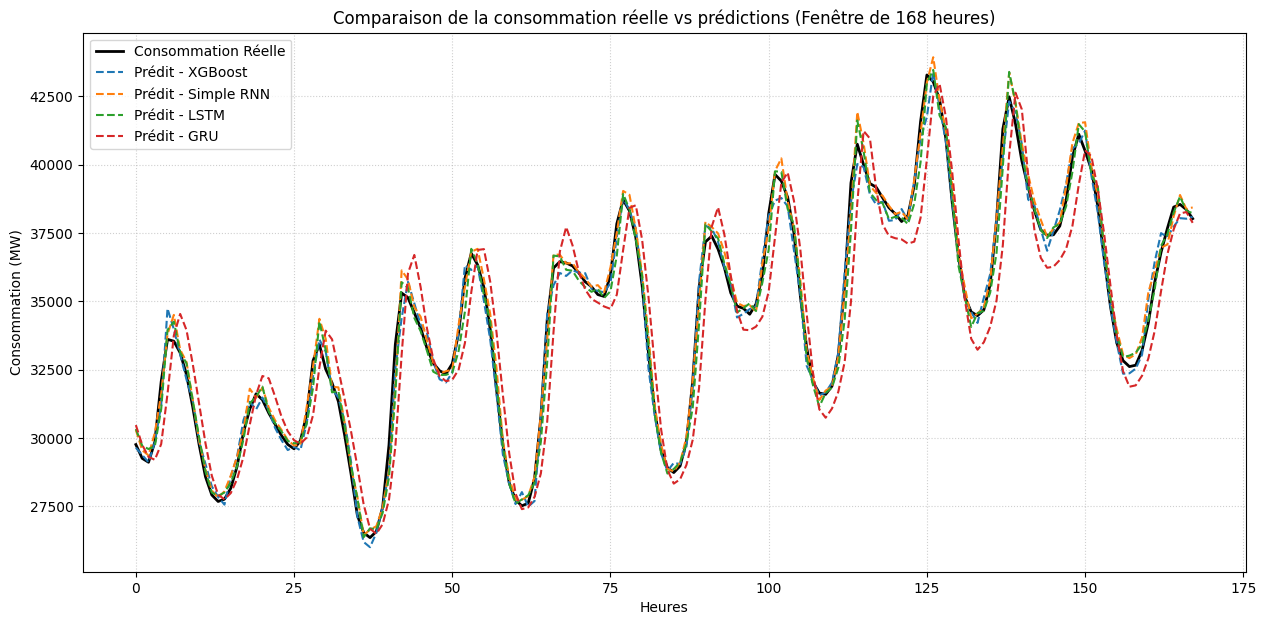

In [11]:
# Visualisation sur une fenêtre d'une semaine (168 heures)
plt.figure(figsize=(15, 7))

# Sélection des 168 derniers éléments de l'ensemble de test pour la clarté visuelle
plot_hours = 168
y_test_sample = y_test_rescaled[:plot_hours]

plt.plot(y_test_sample, label='Consommation Réelle', color='black', linewidth=2)

for name, pred in predictions.items():
    pred_rescaled = scaler.inverse_transform(pred.reshape(-1, 1)).flatten()
    plt.plot(pred_rescaled[:plot_hours], label=f"Prédit - {name}", linestyle='--')

plt.title("Comparaison de la consommation réelle vs prédictions (Fenêtre de 168 heures)")
plt.xlabel("Heures")
plt.ylabel("Consommation (MW)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Sauvegarde du graphique
plt.savefig('comparison_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### 5. Importance des Variables (Feature Importance)

Top 10 des heures les plus influentes :


,Lag,Importance
23,t-1,0.839441
2,t-22,0.032385
20,t-4,0.016288
3,t-21,0.013795
21,t-3,0.012543
1,t-23,0.011389
22,t-2,0.010333
19,t-5,0.008588
13,t-11,0.007589
14,t-10,0.007138


/tmp/ipykernel_1882/3834513034.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Lag', data=df_importance, palette='viridis')


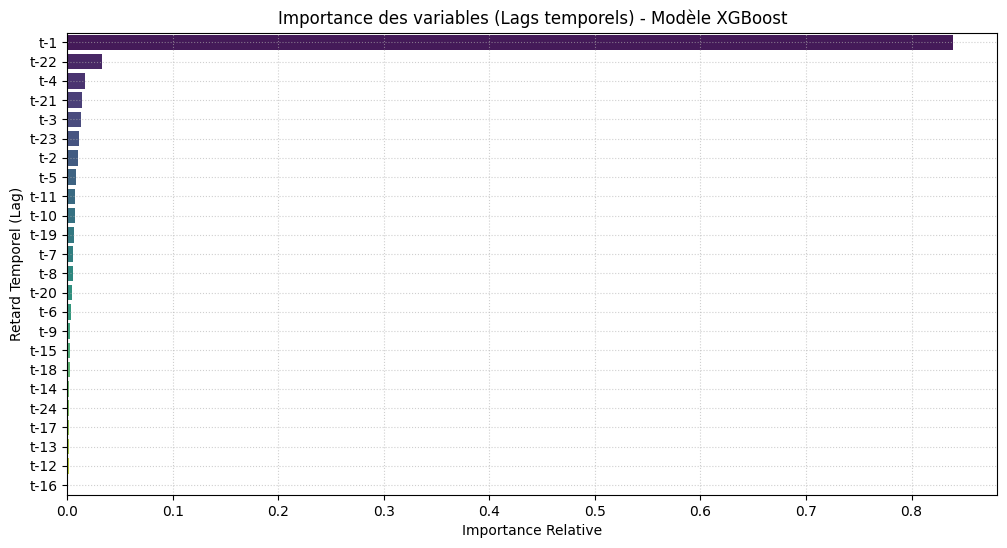

In [12]:
# Extraction de l'importance des features du modèle XGBoost
importances = xgb_model.feature_importances_

# Nos caractéristiques correspondent aux 24 heures précédentes (lags)
feature_names = [f't-{24 - i}' for i in range(24)]

# Création d'un DataFrame pour faciliter la manipulation et l'affichage
df_importance = pd.DataFrame({
    'Lag': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Top 10 des heures les plus influentes :")
display(df_importance.head(10))

# Tracé du graphique d'importance
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Lag', data=df_importance, palette='viridis')
plt.title('Importance des variables (Lags temporels) - Modèle XGBoost')
plt.xlabel('Importance Relative')
plt.ylabel('Retard Temporel (Lag)')
plt.grid(True, linestyle=':', alpha=0.6)

# Sauvegarde du graphique
plt.savefig('feature_importance_plot.png', dpi=300, bbox_inches='tight')
plt.show()

Calcul de l'importance pour Simple RNN...


/tmp/ipykernel_1882/1615832953.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Lag', data=df_imp, palette='magma')


Calcul de l'importance pour LSTM...


/tmp/ipykernel_1882/1615832953.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Lag', data=df_imp, palette='magma')


Calcul de l'importance pour GRU...


/tmp/ipykernel_1882/1615832953.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Lag', data=df_imp, palette='magma')


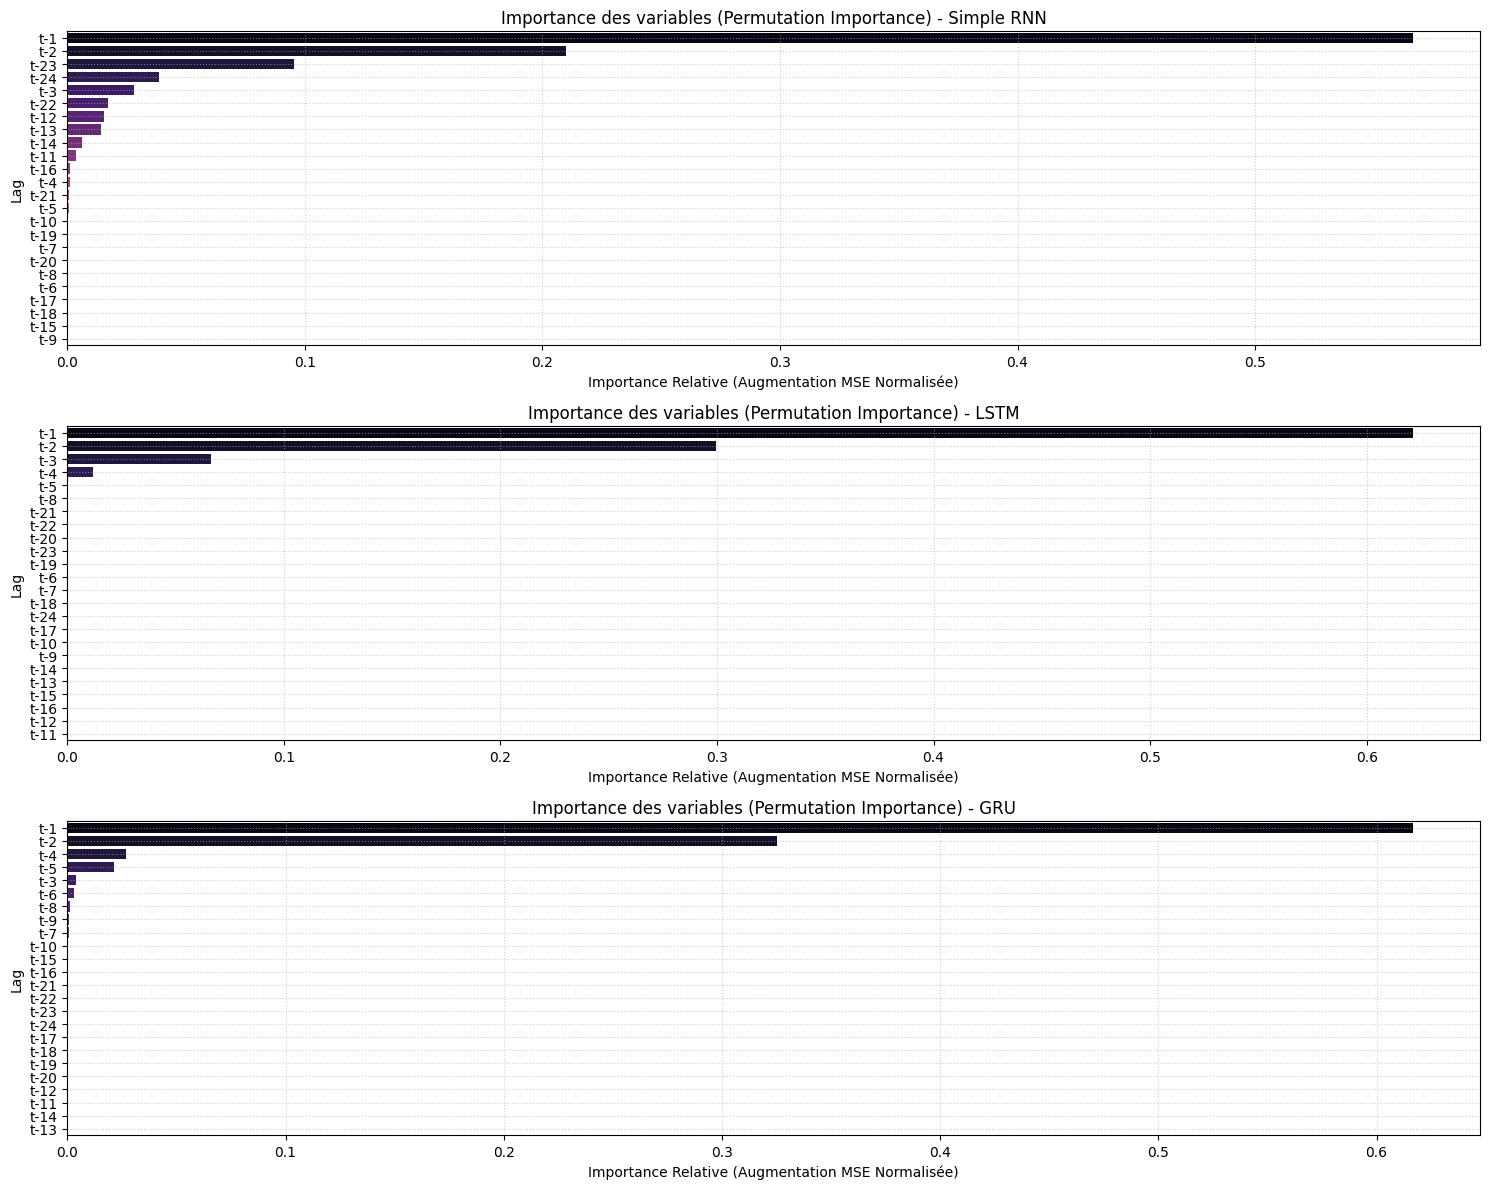

In [13]:
# Calcul de l'importance par permutation pour les modèles RNN, LSTM et GRU
from sklearn.metrics import mean_squared_error

def calculate_permutation_importance(model, X_val, y_val, base_mse):
    importances = []
    # Pour chaque pas de temps (lag de 0 à 23)
    for col in range(X_val.shape[1]):
        # Sauvegarder l'état original
        X_permuted = X_val.copy()
        # Mélanger uniquement ce pas de temps spécifique à travers tous les échantillons
        np.random.shuffle(X_permuted[:, col, 0])
        # Prédire avec les données permutées
        preds = model.predict(X_permuted, verbose=0).flatten()
        permuted_mse = mean_squared_error(y_val, preds)
        # L'importance est l'augmentation de la MSE
        importance = max(0, permuted_mse - base_mse)
        importances.append(importance)
    return np.array(importances)

# Dictionnaire des modèles de Deep Learning à évaluer
dl_models = {
    'Simple RNN': model_rnn,
    'LSTM': model_lstm,
    'GRU': model_gru
}

# Calcul de l'importance pour chaque modèle
plt.figure(figsize=(15, 12))
feature_names = [f't-{24 - i}' for i in range(24)]

for idx, (name, model) in enumerate(dl_models.items(), 1):
    # Calcul de la MSE de base sur l'ensemble de validation
    base_preds = model.predict(X_val, verbose=0).flatten()
    base_mse = mean_squared_error(y_val, base_preds)

    print(f"Calcul de l'importance pour {name}...")
    importances = calculate_permutation_importance(model, X_val, y_val, base_mse)

    # Normalisation pour que la somme soit égale à 1 (comme XGBoost)
    if importances.sum() > 0:
        importances /= importances.sum()

    df_imp = pd.DataFrame({'Lag': feature_names, 'Importance': importances})
    df_imp = df_imp.sort_values(by='Importance', ascending=False)

    # Tracé
    plt.subplot(3, 1, idx)
    sns.barplot(x='Importance', y='Lag', data=df_imp, palette='magma')
    plt.title(f'Importance des variables (Permutation Importance) - {name}')
    plt.xlabel('Importance Relative (Augmentation MSE Normalisée)')
    plt.ylabel('Lag')
    plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('permutation_importance_plots.png', dpi=300, bbox_inches='tight')
plt.show()